In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/creditcard_clean.csv")

df.head()

Matplotlib is building the font cache; this may take a moment.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset shape: (283726, 31)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [3]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


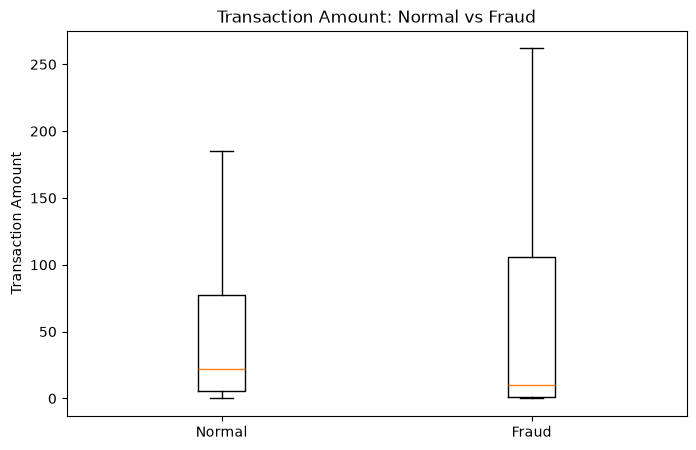

In [8]:
normal_amounts = df[df["Class"] == 0]["Amount"]
fraud_amounts = df[df["Class"] == 1]["Amount"]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [normal_amounts, fraud_amounts],
    tick_labels=["Normal", "Fraud"],
    showfliers=False
)

plt.title("Transaction Amount: Normal vs Fraud")
plt.ylabel("Transaction Amount")
plt.show()

In [9]:
feature_means = df.groupby("Class").mean().T

feature_means.head(10)

Class,0,1
Time,94835.058093,80450.513742
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591
V5,0.006769,-2.957197
V6,0.001251,-1.432518
V7,0.010447,-5.175912
V8,-0.002448,0.953255
V9,0.002613,-2.522124


In [10]:
feature_diff = abs(feature_means[1] - feature_means[0])

feature_diff = feature_diff.drop(["Time", "Amount"])

feature_diff.sort_values(ascending=False).head(10)

V14    6.847614
V3     6.742452
V17    6.474249
V12    6.112730
V10    5.460937
V7     5.186359
V1     4.511719
V4     4.483031
V16    4.008801
V11    3.722350
dtype: float64

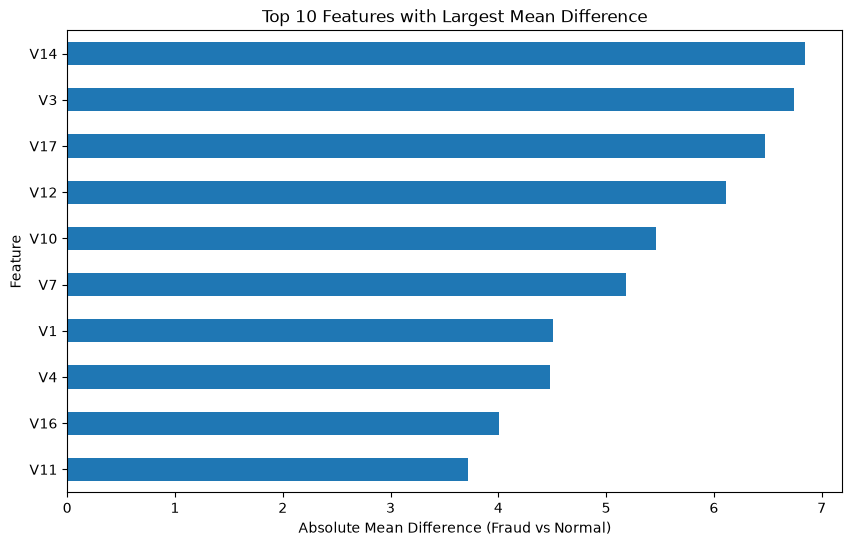

In [11]:
top_features = feature_diff.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

top_features.sort_values().plot(kind="barh")

plt.title("Top 10 Features with Largest Mean Difference")
plt.xlabel("Absolute Mean Difference (Fraud vs Normal)")
plt.ylabel("Feature")
plt.show()

In [14]:
df["Hour"] = df["Time"] / 3600

df.groupby("Class")["Hour"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,26.343072,13.187653,0.000000,15.064722,23.530833,38.696667,47.997778
1,473.0,22.347365,13.510050,0.112778,11.445278,20.391111,35.859722,47.318889
